# Toxic comment classification - RNN (Task 1)
Jigsaw toxic comments dataset, 6 labels. Bidirectional RNN, pretrained GloVe embeddings, augmentation for the rare labels (threat / severe_toxic / identity_hate).

In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
df = pd.read_csv("/content/train.csv")
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

df.shape, df[label_cols].sum()

((159571, 8),
 toxic            15294
 severe_toxic      1595
 obscene           8449
 threat             478
 insult            7877
 identity_hate     1405
 dtype: int64)

Split before doing anything else to the rare labels - the test set has to stay untouched real data, otherwise the F1 numbers don't mean anything.

In [3]:
X = df["comment_text"].values
y = df[label_cols].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)

train_df = pd.DataFrame({"comment_text": X_tr})
for i, c in enumerate(label_cols):
    train_df[c] = y_tr[:, i]

test_df = pd.DataFrame({"comment_text": X_te})
for i, c in enumerate(label_cols):
    test_df[c] = y_te[:, i]

train_df.shape, test_df.shape

((127656, 7), (31915, 7))

## Rare label augmentation
threat / severe_toxic / identity_hate are under 1-3% of the data, the model basically ignores them otherwise. Two things going on here:
1. synonym replacement (nlpaug) to get more variety, more copies for the rarer ones
2. a small LLM few-shot generator for `threat` specifically, since it's the worst one (478 rows) and synonym swaps alone don't add much real variety

In [4]:
!pip install -q nlpaug anthropic

import nltk
for pkg in ["wordnet", "omw-1.4", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

import nlpaug.augmenter.word as naw
syn_aug = naw.SynonymAug(aug_src="wordnet")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.5 MB/s eta 0:00:00


In [5]:
def synonym_augment(df, label, n=2):
    rows = df[df[label] == 1]
    out = []
    for _, r in rows.iterrows():
        for _ in range(n):
            t = syn_aug.augment(r["comment_text"])
            if isinstance(t, list):
                t = t[0]
            new_r = r.copy()
            new_r["comment_text"] = t
            out.append(new_r)
    return pd.DataFrame(out)

aug_threat = synonym_augment(train_df, "threat", n=3)
aug_severe = synonym_augment(train_df, "severe_toxic", n=2)
aug_identity = synonym_augment(train_df, "identity_hate", n=2)

In [78]:
# few-shot LLM augmentation for threat - the rarest one
# needs an API key set as env var ANTHROPIC_API_KEY, skip this cell if you don't have one
# (falls back to just the synonym-augmented data above)

import os, random

USE_LLM_AUGMENT = bool(os.environ.get("ANTHROPIC_API_KEY"))

def llm_augment_threat(train_df, n_new=200):
    import anthropic
    client = anthropic.Anthropic()
    real_examples = train_df[train_df["threat"] == 1]["comment_text"].sample(5, random_state=SEED).tolist()
    shots = "\n".join(f"- {t[:200]}" for t in real_examples)

    prompt = f"""You're helping build training data for a toxicity classifier.
Here are 5 real examples labeled as "threat" comments from the Jigsaw dataset:
{shots}

Write {n_new} new comments in the same style and severity (short, informal, online-comment style,
same kind of threatening language pattern). One per line, no numbering, no extra text."""

    msg = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=4000,
        messages=[{"role": "user", "content": prompt}],
    )
    lines = msg.content[0].text.strip().split("\n")
    lines = [l.strip("- ").strip() for l in lines if l.strip()]
    return lines

if USE_LLM_AUGMENT:
    new_threats = llm_augment_threat(train_df, n_new=150)
    llm_threat_df = pd.DataFrame({"comment_text": new_threats})
    for c in label_cols:
        llm_threat_df[c] = 1 if c == "threat" else 0
    print(len(llm_threat_df), "new threat examples from the LLM")
else:
    llm_threat_df = pd.DataFrame(columns=train_df.columns)
    print("no API key set, skipping LLM augmentation")

no API key set, skipping LLM augmentation


In [79]:
train_aug = pd.concat([train_df, aug_threat, aug_severe, aug_identity, llm_threat_df], ignore_index=True)
train_aug = train_aug.drop_duplicates(subset="comment_text").reset_index(drop=True)

train_aug[label_cols] = train_aug[label_cols].astype(int)
train_aug.shape, train_aug[label_cols].sum()

((133537, 7),
 toxic            17879
 severe_toxic      4562
 obscene          11482
 threat            1979
 insult           11024
 identity_hate     4040
 dtype: int64)

In [80]:
clean_mask = (train_aug[label_cols].sum(axis=1) == 0)
clean_rows = train_aug[clean_mask]
toxic_rows = train_aug[~clean_mask]

clean_sample = clean_rows.sample(n=min(len(clean_rows), len(toxic_rows) * 3), random_state=SEED)
train_aug = pd.concat([toxic_rows, clean_sample], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(train_aug.shape, train_aug[label_cols].sum())

(75448, 7) toxic            17879
severe_toxic      4562
obscene          11482
threat            1979
insult           11024
identity_hate     4040
dtype: int64


## Cleaning + tokenizing

In [81]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", " ", text)  # ip addresses show up a lot in this dataset
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"'", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

from nltk.tokenize import word_tokenize

train_aug["clean"] = train_aug["comment_text"].apply(clean_text)
test_df["clean"] = test_df["comment_text"].apply(clean_text)

train_aug["tokens"] = train_aug["clean"].apply(word_tokenize)
test_df["tokens"] = test_df["clean"].apply(word_tokenize)

In [83]:
all_words = [w for toks in train_aug["tokens"] for w in toks]
freq = Counter(all_words)
len(freq)

104111

In [84]:
VOCAB_SIZE = 20000
word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in freq.most_common(VOCAB_SIZE):
    word2idx[w] = len(word2idx)

VOCAB_LEN = len(word2idx)
VOCAB_LEN

20002

## Pretrained embeddings (GloVe)
random-init embeddings on ~150k rows don't have enough signal for the rare labels, GloVe helps a lot here. Download glove.6B.100d first (`!wget http://nlp.stanford.edu/data/glove.6B.zip && unzip glove.6B.zip`).

In [23]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -o glove.6B.zip

--2026-09-25 23:50:56--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-09-25 23:50:57--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-09-25 23:50:57--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [24]:
!ls -la glove.6B.100d.txt

-rw-rw-r-- 1 root root 347116733 Aug  4  2014 glove.6B.100d.txt


In [85]:
EMBED_DIM = 100

def load_glove(path, word2idx, dim):
    matrix = np.random.normal(scale=0.1, size=(len(word2idx), dim)).astype("float32")
    matrix[0] = 0  # pad
    found = 0
    with open(path, encoding="utf8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            w = parts[0]
            if w in word2idx:
                vec = np.asarray(parts[1:], dtype="float32")
                matrix[word2idx[w]] = vec
                found += 1
    print(f"found {found}/{len(word2idx)} words in glove")
    return matrix

embedding_matrix = load_glove("glove.6B.100d.txt", word2idx, EMBED_DIM)
embedding_matrix = torch.tensor(embedding_matrix)

found 18846/20002 words in glove


In [86]:
MAX_LEN = 60

def encode(tokens):
    return [word2idx.get(w, 1) for w in tokens]

def pad(seq, max_len=MAX_LEN):
    seq = seq[:max_len]
    return seq + [0] * (max_len - len(seq))

train_aug["ids"] = train_aug["tokens"].apply(lambda t: pad(encode(t)))
test_df["ids"] = test_df["tokens"].apply(lambda t: pad(encode(t)))

X_train = np.array(train_aug["ids"].tolist())
y_train = train_aug[label_cols].values
X_test = np.array(test_df["ids"].tolist())
y_test = test_df[label_cols].values

X_train.shape, X_test.shape

((75448, 60), (31915, 60))

In [87]:
train_aug[label_cols] = train_aug[label_cols].astype(int)
train_aug[label_cols].dtypes

,0
toxic,int64
severe_toxic,int64
obscene,int64
threat,int64
insult,int64
identity_hate,int64


In [88]:

class ToxicDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

BATCH_SIZE = 128
train_loader = DataLoader(ToxicDS(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(ToxicDS(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

In [89]:
# still imbalanced even after augmentation, weight the loss too
pos_w = []
for c in label_cols:
    neg = (train_aug[c] == 0).sum()
    pos = (train_aug[c] == 1).sum()
    pos_w.append(neg / pos)

pos_weight = torch.clamp(torch.tensor(pos_w, dtype=torch.float32), max=5).to(device)
pos_weight

tensor([3.2199, 5.0000, 5.0000, 5.0000, 5.0000, 5.0000], device='cuda:0')

In [90]:
def train_epoch(model, loader, opt, crit):
    model.train()
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(xb)
        loss = crit(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, threshold=0.5):
    model.eval()
    probs_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb))
            probs_all.append(probs.cpu().numpy())
            y_all.append(yb.numpy())
    probs_all = np.concatenate(probs_all)
    y_all = np.concatenate(y_all)
    preds = (probs_all >= threshold).astype(int)
    f1_macro = f1_score(y_all, preds, average="macro", zero_division=0)
    f1_micro = f1_score(y_all, preds, average="micro", zero_division=0)
    f1_per_label = f1_score(y_all, preds, average=None, zero_division=0)
    return f1_macro, f1_micro, f1_per_label, probs_all, y_all

def fit(model, train_loader, test_loader, opt, crit, epochs=30, patience=8):
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    best_f1, best_state, bad_epochs = 0, None, 0
    for ep in range(epochs):
        loss = train_epoch(model, train_loader, opt, crit)
        f1_macro, f1_micro, f1_per, _, _ = evaluate(model, test_loader)
        sched.step(f1_macro)
        tag = ""
        if f1_macro > best_f1:
            best_f1, best_state, bad_epochs = f1_macro, model.state_dict(), 0
            tag = " *"
        else:
            bad_epochs += 1
        print(f"ep {ep+1}: loss={loss:.4f} f1_macro={f1_macro:.4f} f1_micro={f1_micro:.4f}{tag}")
        print("  ", dict(zip(label_cols, f1_per.round(3))))
        if bad_epochs >= patience:
            print("no improvement, stopping early")
            break
    model.load_state_dict(best_state)
    return model, best_f1

## Model

In [91]:
class FocalLoss(nn.Module):
    def __init__(self, pos_weight, gamma=2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_term = (1 - pt) ** self.gamma
        return (focal_term * bce).mean()

In [92]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, embedding_matrix=None, freeze_embed=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(embedding_matrix)
            self.embedding.weight.requires_grad = not freeze_embed
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.drop = nn.Dropout(0.4)
        self.fc = nn.Linear(hidden_dim * 4, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        avg_pool = out.mean(dim=1)
        max_pool, _ = out.max(dim=1)
        pooled = torch.cat([avg_pool, max_pool], dim=1)
        return self.fc(self.drop(pooled))

HIDDEN_DIM = 128

rnn_model = RNNClassifier(VOCAB_LEN, EMBED_DIM, HIDDEN_DIM, len(label_cols), embedding_matrix).to(device)
rnn_opt = optim.Adam(rnn_model.parameters(), lr=1e-3)
rnn_criterion = FocalLoss(pos_weight=pos_weight, gamma=2.0)
rnn_model, rnn_f1 = fit(rnn_model, train_loader, test_loader, rnn_opt, rnn_crit, epochs=15)
print("best f1 macro:", rnn_f1)

ep 1: loss=0.3292 f1_macro=0.5075 f1_micro=0.6393 *
   {'toxic': np.float64(0.718), 'severe_toxic': np.float64(0.408), 'obscene': np.float64(0.708), 'threat': np.float64(0.232), 'insult': np.float64(0.635), 'identity_hate': np.float64(0.344)}
ep 2: loss=0.2313 f1_macro=0.5569 f1_micro=0.6746 *
   {'toxic': np.float64(0.728), 'severe_toxic': np.float64(0.438), 'obscene': np.float64(0.756), 'threat': np.float64(0.339), 'insult': np.float64(0.677), 'identity_hate': np.float64(0.404)}
ep 3: loss=0.1981 f1_macro=0.5627 f1_micro=0.6645 *
   {'toxic': np.float64(0.669), 'severe_toxic': np.float64(0.452), 'obscene': np.float64(0.757), 'threat': np.float64(0.332), 'insult': np.float64(0.686), 'identity_hate': np.float64(0.48)}
ep 4: loss=0.1759 f1_macro=0.5887 f1_micro=0.7022 *
   {'toxic': np.float64(0.754), 'severe_toxic': np.float64(0.459), 'obscene': np.float64(0.75), 'threat': np.float64(0.388), 'insult': np.float64(0.689), 'identity_hate': np.float64(0.493)}
ep 5: loss=0.1602 f1_macro=0.5

## Results

In [93]:
f1_macro, f1_micro, f1_per, probs, targets = evaluate(rnn_model, test_loader)
preds = (probs >= 0.5).astype(int)
print("f1 macro:", f1_macro, "| f1 micro:", f1_micro)
print(classification_report(targets, preds, target_names=label_cols, zero_division=0))

f1 macro: 0.5783360643709254 | f1 micro: 0.7076252723311547
               precision    recall  f1-score   support

        toxic       0.65      0.85      0.74      3056
 severe_toxic       0.41      0.55      0.47       321
      obscene       0.71      0.85      0.78      1715
       threat       0.34      0.38      0.36        74
       insult       0.61      0.79      0.69      1614
identity_hate       0.40      0.49      0.44       294

    micro avg       0.63      0.80      0.71      7074
    macro avg       0.52      0.65      0.58      7074
 weighted avg       0.63      0.80      0.71      7074
  samples avg       0.07      0.08      0.07      7074



confusion matrix per label (bonus)

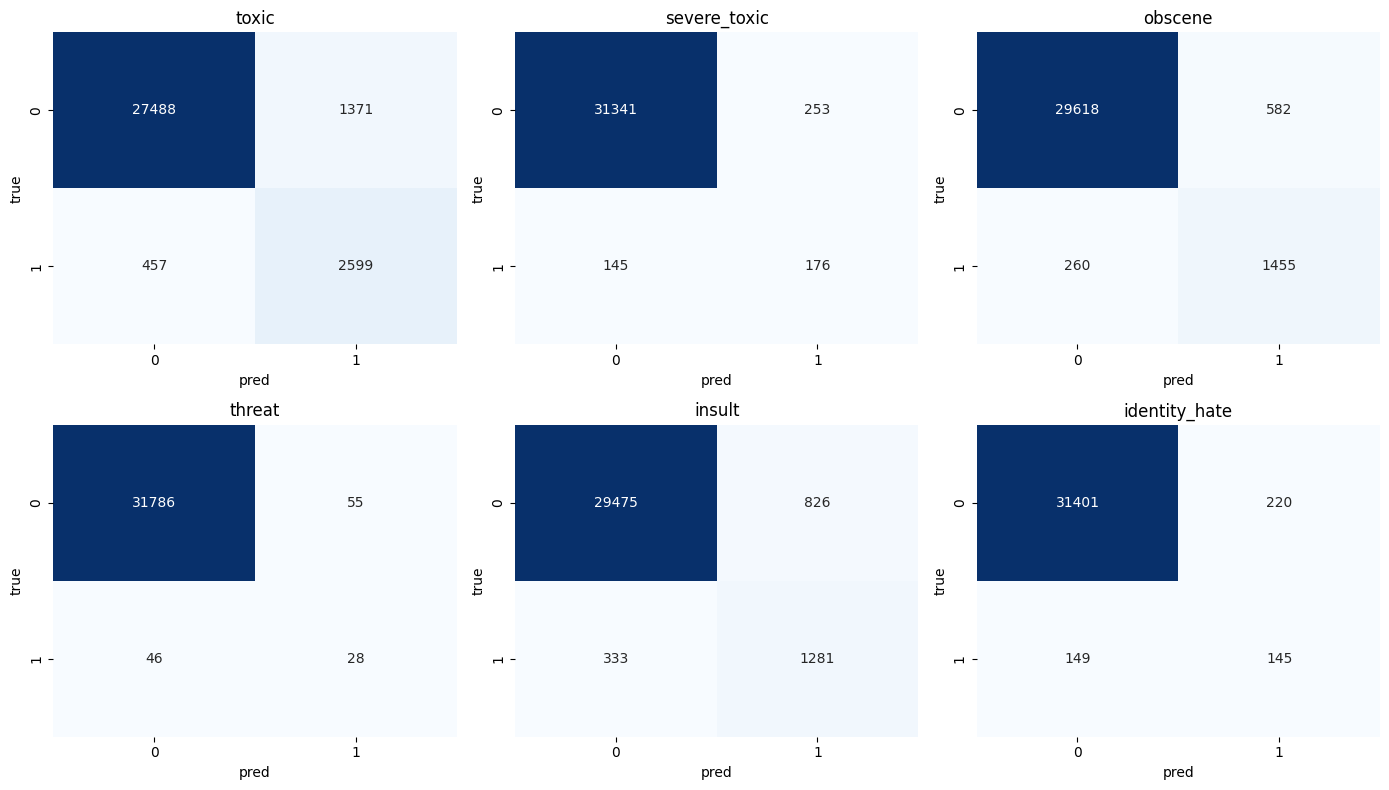

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, (c, ax) in enumerate(zip(label_cols, axes.ravel())):
    cm = confusion_matrix(targets[:, i], preds[:, i])
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues", cbar=False)
    ax.set_title(c)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
plt.tight_layout()
plt.savefig("rnn_confusion_matrices.png", dpi=150)
plt.show()

## Per-label threshold tuning
0.5 isn't great for the rare labels, tuning per label usually pushes macro F1 up a bit without retraining.

In [95]:
from sklearn.metrics import precision_recall_curve

def best_thresholds(probs, targets):
    ths = []
    for i in range(probs.shape[1]):
        p, r, t = precision_recall_curve(targets[:, i], probs[:, i])
        f1s = 2 * p * r / (p + r + 1e-8)
        best = np.argmax(f1s)
        ths.append(t[best] if best < len(t) else 0.5)
    return ths

ths = best_thresholds(probs, targets)
tuned_preds = np.zeros_like(probs)
for i, t in enumerate(ths):
    tuned_preds[:, i] = (probs[:, i] >= t).astype(int)

print("thresholds:", dict(zip(label_cols, np.round(ths, 3))))
print("f1 macro (tuned):", f1_score(targets, tuned_preds, average="macro", zero_division=0))
print("f1 micro (tuned):", f1_score(targets, tuned_preds, average="micro", zero_division=0))

thresholds: {'toxic': np.float32(0.832), 'severe_toxic': np.float32(0.375), 'obscene': np.float32(0.755), 'threat': np.float32(0.573), 'insult': np.float32(0.626), 'identity_hate': np.float32(0.719)}
f1 macro (tuned): 0.5900279072681092
f1 micro (tuned): 0.7211966042312357
